In [1]:
# Import necessary packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [2]:
clust_pos = pd.read_csv('ssgsea_cluster_all_trns_Homoharringtonine.csv')
ctrl_pos = pd.read_csv('ssgsea_cluster_all_trns_DMSO_TF.csv')
ctrl_neg = pd.read_csv('ssgsea_other_all_trns_DMSO_TF.csv')

In [3]:
# Order data
data = [
    clust_pos['TEAD2'],   # KRAS+ treated
    ctrl_pos['TEAD2'],    # KRAS+ DMSO
    ctrl_neg['TEAD2']     # KRAS– DMSO
]
labels = ['clust_pos_treated', 'clust_pos_DMSO', 'clust_neg_DMSO']

# Significance tests
p1 = mannwhitneyu(data[0], data[1], alternative='two-sided').pvalue 
p2 = mannwhitneyu(data[1], data[2], alternative='two-sided').pvalue  


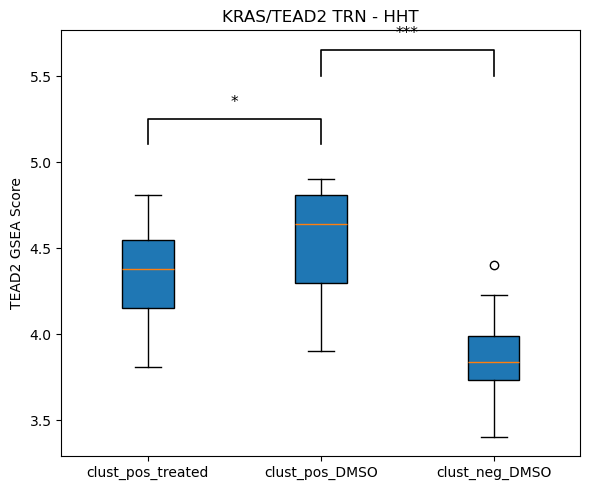

In [4]:
# Plot
plt.figure(figsize=(6, 5))
plt.boxplot(data, labels=labels, patch_artist=True)
plt.title('KRAS/TEAD2 TRN - HHT')
plt.ylabel('TEAD2 GSEA Score')

# Function to draw significance bars
def add_sig_bar(x1, x2, y, pval, h=0.15):
    plt.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.2, c='black')
    if pval < 0.001:
        sig = '***'
    elif pval < 0.01:
        sig = '**'
    elif pval < 0.05:
        sig = '*'
    else:
        sig = 'ns'
    plt.text((x1 + x2) * 0.5, y + h + 0.05, sig, ha='center', va='bottom', fontsize=11)

# Add significance bars
y_max = max([d.max() for d in data])
add_sig_bar(1, 2, y_max + 0.2, p1)   # clust_pos_treated vs clust_pos_DMSO
add_sig_bar(2, 3, y_max + 0.6, p2)   # clust_pos_DMSO vs clust_neg_DMSO

plt.tight_layout()
plt.show()